In [208]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")
import random
from matplotlib import pyplot as plt
%matplotlib notebook
%matplotlib inline

In [209]:
df = pd.read_csv("8) homeprices_banglore.csv")
df.sample(5)

,area,bedrooms,price
12,1000,2,38.0
13,1100,2,40.0
8,1310,3,50.0
17,1540,3,60.0
4,1200,2,51.0


In [210]:
scalerx = MinMaxScaler()
scalery = MinMaxScaler()
x = scalerx.fit_transform(df.drop(columns=["price"], axis="columns"))
y = scalery.fit_transform(df["price"].values.reshape(df.shape[0], 1)).reshape(y.shape[0],)

In [211]:
def vanilla_gradient_descent(x,y,epochcount,rate=0.005):
  w = np.ones(shape=(x.shape[1]))
  b = 0
  total_samples = x.shape[0]
  costs = []
  epochs = []
  for i in range(epochcount):
    y_pred = np.dot(w, x.T) + b
    w_grad = -(1/total_samples)*(x.T.dot(y-y_pred))
    b_grad = -(1/total_samples)*np.sum(y-y_pred)
    w = w - rate*w_grad
    b = b - rate*b_grad
    cost = np.mean(np.square(y-y_pred))
    if i%10==0:
      costs.append(cost)
      epochs.append(i)
  return w,b,cost,costs,epochs
w1, b1, cost1, costs1, epochs1 = vanilla_gradient_descent(x,y,10000)
w1, float(b1), float(cost1)

(array([0.68547768, 0.50901579]), -0.13674427150015606, 0.003991017658027304)

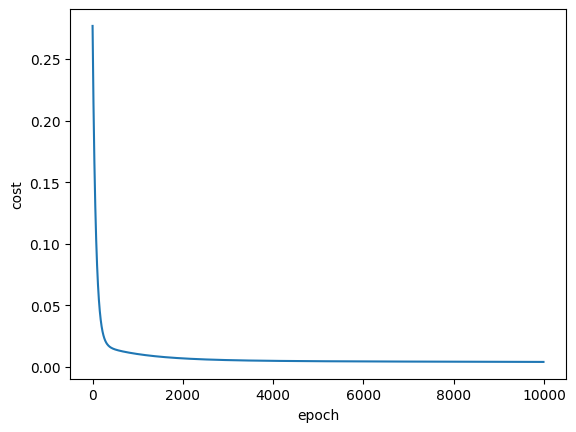

In [212]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epochs1, costs1)
plt.show()

In [213]:
def predict1(x1,x2,w=w1,b=b1):
  x1 = scalerx.transform([[x1,x2]])[0]
  scaled_price = w[0]*x1[0] + w[1]*x1[1] + b
  return scalery.inverse_transform([[scaled_price]])[0][0]

In [214]:
print(predict1(1200,2), predict1(500,9), predict1(20000,30))

43.482873304500615 141.40073525997127 1124.41394834453


In [215]:
def stochastic_gradient_descent(x,y,epochcount,rate=0.005):
  w = np.ones(shape=(x.shape[1]))
  b = 0
  total_samples = x.shape[0]
  costs = []
  epochs = []
  for i in range(epochcount):
    rand_ind = random.randint(0, total_samples-1)
    samp_x = x[rand_ind]
    samp_y = y[rand_ind]
    y_pred = np.dot(w,samp_x.T) + b
    w_grad = -(samp_x.T.dot(samp_y-y_pred))
    b_grad = -(samp_y-y_pred)
    w = w - rate*w_grad
    b = b - rate*b_grad
    cost = np.mean(np.square(samp_y-y_pred))
    if i%10==0:
      costs.append(cost)
      epochs.append(i)
  return w,b,cost,costs,epochs
w2, b2, cost2, costs2, epochs2 = stochastic_gradient_descent(x,y,10000)
w2, float(b2), float(cost2)

(array([0.68931344, 0.50163577]), -0.13498069846483382, 1.2061848896722686e-06)

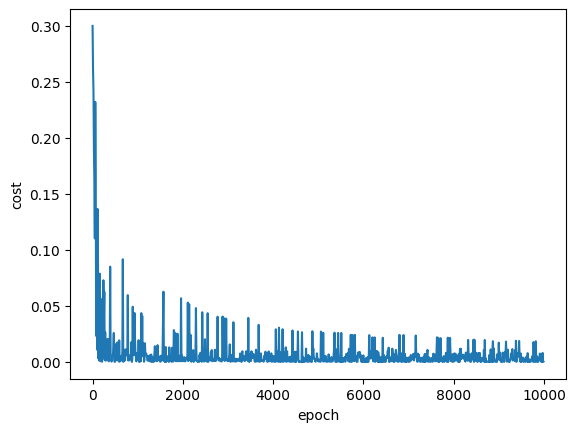

In [216]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epochs2, costs2)
plt.show()

In [217]:
def predict2(x1,x2,w=w2,b=b2):
  x1 = scalerx.transform([[x1,x2]])[0]
  scaled_price = w[0]*x1[0] + w[1]*x1[1] + b
  return scalery.inverse_transform([[scaled_price]])[0][0]

In [218]:
print(predict2(1200,2), predict2(500,9), predict2(20000,30))

43.54330475017673 139.59264553359787 1120.857220560722


In [219]:
def minibatch_gradient_descent(x,y,epochcount,rate=0.005,batch_size=10,randomize=False):
  w=np.ones((x.shape[1],))
  b=0
  costs=[]
  epochs=[]
  total_samples=x.shape[0]
  for i in range(epochcount):
    ind=np.random.randint(0,total_samples-batch_size+1) if randomize else (i*batch_size)%total_samples
    samp_x=x[ind:ind+batch_size]
    samp_y=y[ind:ind+batch_size]
    y_pred=np.dot(w,samp_x.T)+b
    w_grad=-(1/batch_size)*(samp_x.T.dot(samp_y-y_pred))
    b_grad=-(1/batch_size)*np.sum(samp_y-y_pred)
    w=w-rate*w_grad
    b=b-rate*b_grad
    cost=np.mean(np.square(samp_y-y_pred))
    if i%10==0:
      costs.append(cost);epochs.append(i)
  return w,b,cost,costs,epochs
w3, b3, cost3, costs3, epochs3=minibatch_gradient_descent(x,y,10000,randomize=True, batch_size = 7)
w3, float(b3), float(cost3)

(array([0.69439888, 0.55699649]), -0.1626732705767783, 0.002106657984215137)

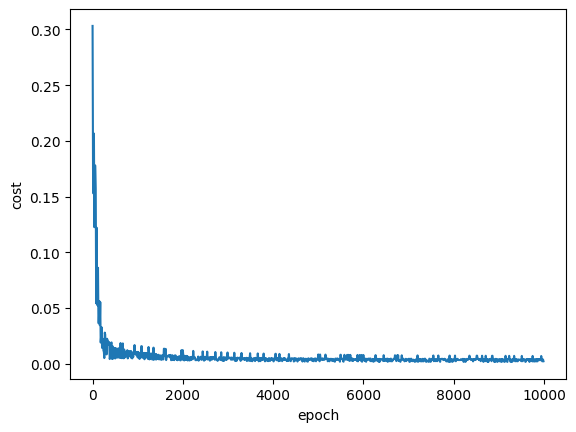

In [220]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epochs3, costs3)
plt.show()

In [221]:
def predict3(x1,x2,w=w3,b=b3):
  x1 = scalerx.transform([[x1,x2]])[0]
  scaled_price = w[0]*x1[0] + w[1]*x1[1] + b
  return scalery.inverse_transform([[scaled_price]])[0][0]

In [222]:
print(predict3(1200,2), predict3(500,9), predict3(20000,30))

41.767926099067864 150.7305217523551 1175.8483541640041
